# German Installed Wind + Solar Capacity (MaStR)

A stripped-down first look at `energy-data-hub`'s MaStR-derived wind +
solar capacity data:
- overview statistics on the raw unit-level data
- how installed solar/wind capacity has grown over time
- where solar and wind capacity is located across German NUTS3 regions
- an animated map of solar & wind capacity growth, year by year

**Deliberately not covered here** (see `energy-insights` repo roadmap):
storage/biomass/hydro/gsgk capacity (the hub doesn't ingest those
technologies yet) and the behind-the-meter PV category breakdown (that's
its own page, once the hub's `pv_category` data has had more validation) --
and a MaStR-vs-SMARD installed-capacity comparison, which is its own
separate page too.

In [1]:
import io

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from insights.paths import INSIGHTS_ROOT, hub_file

events = pd.read_parquet(hub_file("capacity", "capacity_events.parquet"))
panel = pd.read_parquet(hub_file("capacity", "capacity_by_region_year.parquet"))
regions = gpd.read_file(hub_file("regions", "nuts_regions.geojson"))

TECHNOLOGY_ORDER = ["wind", "solar"]
TECHNOLOGY_COLORS = {"wind": "#1B7A9C", "solar": "#E8A33D"}

# Solar and wind only really take off from ~1990 onward.
CHART_START_YEAR = 1990

## Overview

In [2]:
print(f"Units: {len(events):,}")
print(f"Total installed capacity: {events['capacity_mw'].sum():,.0f} MW")
print(
    "Commissioning dates: "
    f"{events['commissioning_date'].min().date()} - {events['commissioning_date'].max().date()}"
)
print("\nUnits and capacity by technology:")
print(
    events.groupby("technology")
    .agg(units=("unit_id", "count"), capacity_mw=("capacity_mw", "sum"))
    .reindex(TECHNOLOGY_ORDER)
    .round(0)
)

Units: 6,269,286
Total installed capacity: 195,846 MW
Commissioning dates: 1900-01-01 - 2026-07-16

Units and capacity by technology:
              units  capacity_mw
technology                      
wind          34930      84027.0
solar       6234356     111819.0


## Solar & wind installed capacity over time

National total installed capacity at the end of each year, based on
commissioning and final-shutdown dates (fixed current NUTS3 boundaries;
only the capacity mix changes across years).

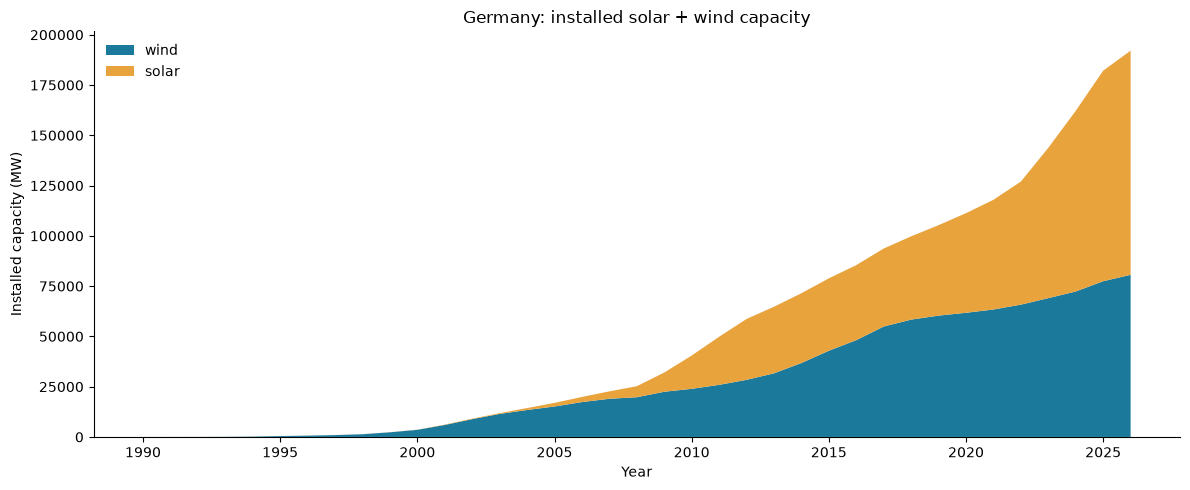

In [3]:
national = panel.groupby(["year", "technology"])["capacity_mw"].sum().unstack("technology")
national = national.reindex(columns=TECHNOLOGY_ORDER, fill_value=0.0)
national = national[national.index >= CHART_START_YEAR]

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(
    national.index,
    [national[tech] for tech in TECHNOLOGY_ORDER],
    labels=TECHNOLOGY_ORDER,
    colors=[TECHNOLOGY_COLORS[tech] for tech in TECHNOLOGY_ORDER],
)
ax.set_xlabel("Year")
ax.set_ylabel("Installed capacity (MW)")
ax.set_title("Germany: installed solar + wind capacity")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Where is solar capacity installed? (latest snapshot)

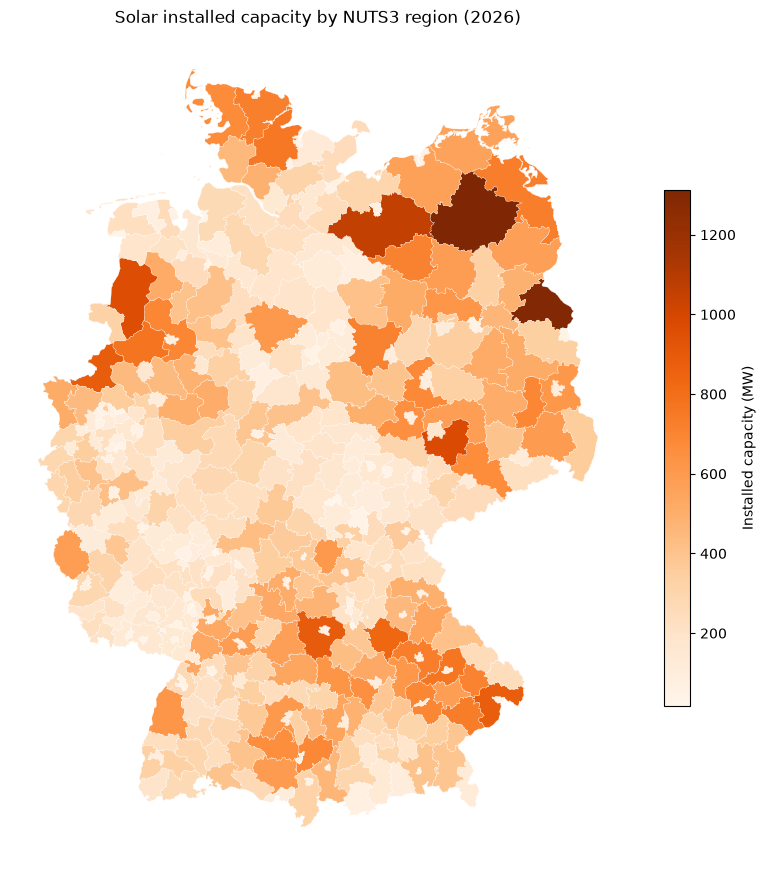

In [4]:
latest_year = panel["year"].max()
latest = panel[panel["year"] == latest_year]

nuts3 = regions[regions["LEVL_CODE"] == 3].copy()

solar_by_region = latest[latest["technology"] == "solar"].groupby("region_code")["capacity_mw"].sum()
nuts3["solar_capacity_mw"] = nuts3["NUTS_ID"].map(solar_by_region).fillna(0.0)

fig, ax = plt.subplots(figsize=(8, 9))
nuts3.plot(
    column="solar_capacity_mw",
    cmap="Oranges",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Installed capacity (MW)", "shrink": 0.6},
    ax=ax,
)
ax.set_title(f"Solar installed capacity by NUTS3 region ({latest_year})")
ax.axis("off")
fig.tight_layout()
plt.show()

## Where is wind capacity installed? (latest snapshot)

Onshore wind is mapped by NUTS3 region. Offshore wind has no NUTS3 region
of its own, and its per-cluster capacity is an order of magnitude larger
than any single onshore region, so it's shown as a separate bar chart.

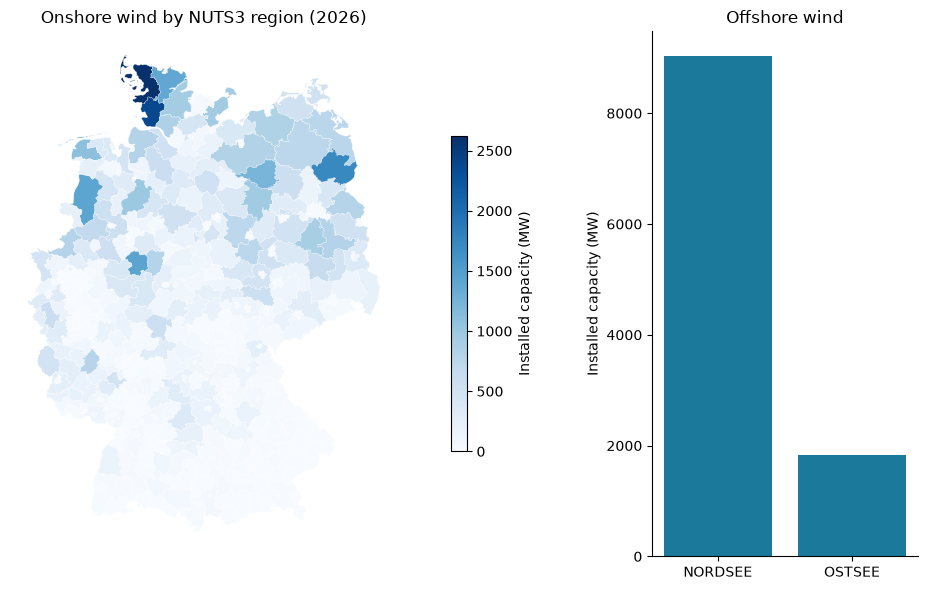

In [5]:
wind_by_region = latest[
    (latest["technology"] == "wind") & (~latest["region_code"].str.startswith("DEZZ"))
].groupby("region_code")["capacity_mw"].sum()
nuts3["wind_capacity_mw"] = nuts3["NUTS_ID"].map(wind_by_region).fillna(0.0)

offshore = latest[
    (latest["technology"] == "wind") & latest["region_code"].str.startswith("DEZZ")
].groupby("region_code")["capacity_mw"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [4, 1]})

nuts3.plot(
    column="wind_capacity_mw",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Installed capacity (MW)", "shrink": 0.6},
    ax=axes[0],
)
axes[0].set_title(f"Onshore wind by NUTS3 region ({latest_year})")
axes[0].axis("off")

axes[1].bar(offshore.index.str.replace("DEZZ-", ""), offshore.values, color=TECHNOLOGY_COLORS["wind"])
axes[1].set_title("Offshore wind")
axes[1].set_ylabel("Installed capacity (MW)")
axes[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

## Offshore wind footprints

Germany's offshore wind clusters (North Sea / Baltic Sea) have no NUTS
region of their own. Instead of a single representative point, this plots
an actual footprint polygon per cluster -- the convex hull of every
currently-installed offshore turbine's real coordinates, against
neighboring countries' coastlines for context.

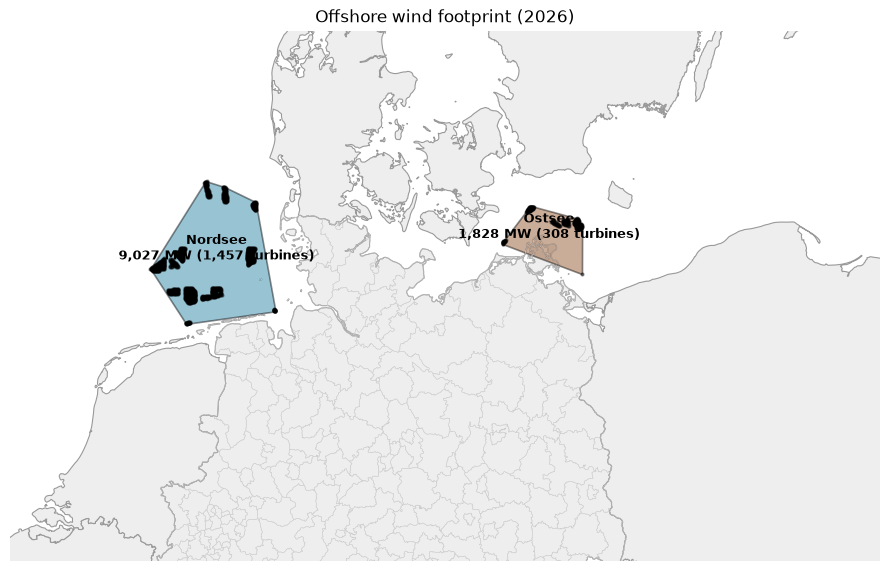

In [6]:
country_borders = gpd.read_file(hub_file("regions", "country_borders.geojson"))
offshore_regions = gpd.read_file(hub_file("capacity", "offshore_regions.geojson"))
snapshot_date = pd.Timestamp(year=latest_year, month=12, day=31)

offshore_units = events[
    (events["technology"] == "wind")
    & events["region_code"].str.startswith("DEZZ")
    & (events["commissioning_date"] <= snapshot_date)
    & (events["final_shutdown_date"].isna() | (events["final_shutdown_date"] > snapshot_date))
].dropna(subset=["longitude", "latitude"])

OFFSHORE_COLORS = {"DEZZ-NORDSEE": "#1B7A9C", "DEZZ-OSTSEE": "#8B4A1E"}

fig, ax = plt.subplots(figsize=(9, 9))
country_borders.plot(ax=ax, facecolor="#eeeeee", edgecolor="#999999", linewidth=0.8)
nuts3.boundary.plot(ax=ax, color="#cccccc", linewidth=0.3)
for _, row in offshore_regions.iterrows():
    gpd.GeoSeries([row["geometry"]], crs="EPSG:4326").plot(
        ax=ax, color=OFFSHORE_COLORS[row["region_code"]], alpha=0.45, edgecolor="black", linewidth=1.2
    )
    centroid = row["geometry"].centroid
    ax.annotate(
        f"{row['region_code'].replace('DEZZ-', '').title()}\n"
        f"{row['capacity_mw']:,.0f} MW ({row['turbine_count']:,} turbines)",
        (centroid.x, centroid.y),
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
ax.scatter(offshore_units["longitude"], offshore_units["latitude"], s=4, color="black", alpha=0.4, zorder=5)
ax.set_xlim(3, 20)
ax.set_ylim(51, 57)
ax.set_title(f"Offshore wind footprint ({latest_year})")
ax.axis("off")
fig.tight_layout()
plt.show()

## Solar & wind installed capacity, year by year

Animated end-of-year snapshots from 1990 to the latest year. Each
technology uses a fixed color scale (0 to that technology's all-time
regional maximum) across every frame, so color darkening over time
reflects real growth rather than a rescaled axis.

In [7]:
solar_pivot = panel[panel["technology"] == "solar"].pivot_table(index="region_code", columns="year", values="capacity_mw", fill_value=0.0)
wind_pivot = panel[(panel["technology"] == "wind") & (~panel["region_code"].str.startswith("DEZZ"))].pivot_table(
    index="region_code", columns="year", values="capacity_mw", fill_value=0.0
)

anim_years = [y for y in range(CHART_START_YEAR, latest_year + 1) if y in solar_pivot.columns]
solar_vmax = solar_pivot.loc[:, anim_years].values.max()
wind_vmax = wind_pivot.loc[:, anim_years].values.max()

frames = []
for year in anim_years:
    nuts3["solar_frame"] = nuts3["NUTS_ID"].map(solar_pivot[year]).fillna(0.0)
    nuts3["wind_frame"] = nuts3["NUTS_ID"].map(wind_pivot[year]).fillna(0.0)

    fig, axes = plt.subplots(1, 2, figsize=(11, 6.5))
    nuts3.plot(column="solar_frame", cmap="Oranges", vmin=0, vmax=solar_vmax, linewidth=0.1, edgecolor="white", legend=True, legend_kwds={"shrink": 0.5}, ax=axes[0])
    nuts3.plot(column="wind_frame", cmap="Blues", vmin=0, vmax=wind_vmax, linewidth=0.1, edgecolor="white", legend=True, legend_kwds={"shrink": 0.5}, ax=axes[1])
    axes[0].set_title("Solar")
    axes[1].set_title("Wind (onshore)")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"Installed capacity — end of {year}")
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    frames.append(Image.open(buf).convert("RGB"))

# Saved next to where the executed notebook lands -- anchored via
# INSIGHTS_ROOT rather than a relative path, since jupytext executes with
# cwd relative to the *source* file (pages/), not the repo root.
gif_path = INSIGHTS_ROOT / "book" / "notebooks" / "capacity_map_animation.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=350, loop=0)
print(f"Saved {len(frames)}-frame animation -> {gif_path}")

Saved 37-frame animation -> /home/chris/research/energy-insights/book/notebooks/capacity_map_animation.gif


```{figure} capacity_map_animation.gif
:name: fig-capacity-map-animation
Solar and onshore wind installed capacity by NUTS3 region, animated
end-of-year snapshots.
```